# PINN experiment notebook

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch import nn

from data_generation import get_initial_condition, get_time_sampling
from net import PINN
from train_test import train_loop

sns.set()

In [2]:
# get the initial conditions, and the training input for the Net
initial_conditions = get_initial_condition()
input = get_time_sampling(max_time=2.0, num_samples=1000)
print(initial_conditions)
print(input.shape)

{'time-positon': (0, 1), 'time-speed': (0, 1)}
torch.Size([1000, 1])


In [3]:
# get model
model = PINN()
print(model)

PINN(
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=1, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=1, bias=True)
  )
)


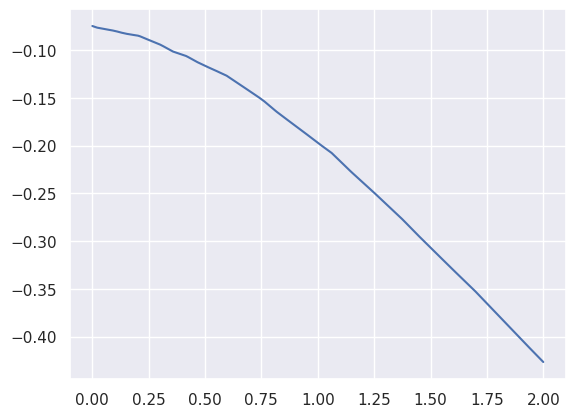

In [4]:
# see initial result for model output
output = model(input)
# As the output is one-dimensional, we can easily visualize it with respect to the input
plt.figure()
plt.plot(input.detach().numpy(), output.detach().numpy())
plt.show()

In [5]:
# define the optimizer
learning_rate = 1e-3
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
train_loop(input, model, optimizer)

Loss: 0.585967 [   10/  100]
Loss: 0.415354 [   30/  100]
Loss: 0.399175 [   50/  100]
Loss: 0.572094 [   70/  100]
Loss: 0.238928 [   90/  100]
Loss: 0.216658 [  110/  100]
Loss: 0.335718 [  130/  100]
Loss: 0.168148 [  150/  100]
Loss: 0.202586 [  170/  100]
Loss: 0.242187 [  190/  100]
Loss: 0.177592 [  210/  100]
Loss: 0.197458 [  230/  100]
Loss: 0.185607 [  250/  100]
Loss: 0.152471 [  270/  100]
Loss: 0.146751 [  290/  100]
Loss: 0.068625 [  310/  100]
Loss: 0.168650 [  330/  100]
Loss: 0.049084 [  350/  100]
Loss: 0.108773 [  370/  100]
Loss: 0.092640 [  390/  100]
Loss: 0.169954 [  410/  100]
Loss: 0.093415 [  430/  100]
Loss: 0.170343 [  450/  100]
Loss: 0.180659 [  470/  100]
Loss: 0.077441 [  490/  100]
Loss: 0.052852 [  510/  100]
Loss: 0.081548 [  530/  100]
Loss: 0.075498 [  550/  100]
Loss: 0.062122 [  570/  100]
Loss: 0.122726 [  590/  100]
Loss: 0.105323 [  610/  100]
Loss: 0.084748 [  630/  100]
Loss: 0.146625 [  650/  100]
Loss: 0.159817 [  670/  100]
Loss: 0.145914

/home/ssuarez/tutorials/pytorch_tutorial/.env/lib/python3.9/site-packages/torch/autograd/__init__.py:251: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 11050). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at ../c10/cuda/CUDAFunctions.cpp:108.)
  Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


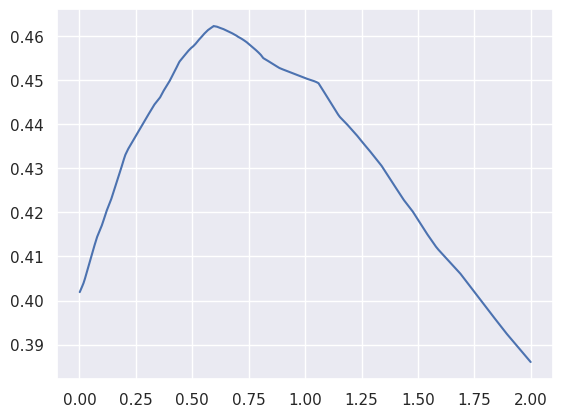

In [6]:
output = model(input)
plt.figure()
plt.plot(input.detach().numpy(), output.detach().numpy())
plt.show()

Epoch 1
----------------------------
Loss: 0.060609 [   10/  100]
Loss: 0.067951 [   30/  100]
Loss: 0.121553 [   50/  100]
Loss: 0.102665 [   70/  100]
Loss: 0.057245 [   90/  100]
Loss: 0.059345 [  110/  100]
Loss: 0.117740 [  130/  100]
Loss: 0.093143 [  150/  100]
Loss: 0.083976 [  170/  100]
Loss: 0.084971 [  190/  100]
Loss: 0.050414 [  210/  100]
Loss: 0.080975 [  230/  100]
Loss: 0.093783 [  250/  100]
Loss: 0.059434 [  270/  100]
Loss: 0.090408 [  290/  100]
Loss: 0.076402 [  310/  100]
Loss: 0.097622 [  330/  100]
Loss: 0.096935 [  350/  100]
Loss: 0.059059 [  370/  100]
Loss: 0.052629 [  390/  100]
Loss: 0.033876 [  410/  100]
Loss: 0.066595 [  430/  100]
Loss: 0.072664 [  450/  100]
Loss: 0.046372 [  470/  100]
Loss: 0.053480 [  490/  100]
Loss: 0.064688 [  510/  100]
Loss: 0.073256 [  530/  100]
Loss: 0.094678 [  550/  100]
Loss: 0.045653 [  570/  100]
Loss: 0.054161 [  590/  100]
Loss: 0.064400 [  610/  100]
Loss: 0.048967 [  630/  100]
Loss: 0.058845 [  650/  100]
Loss: 

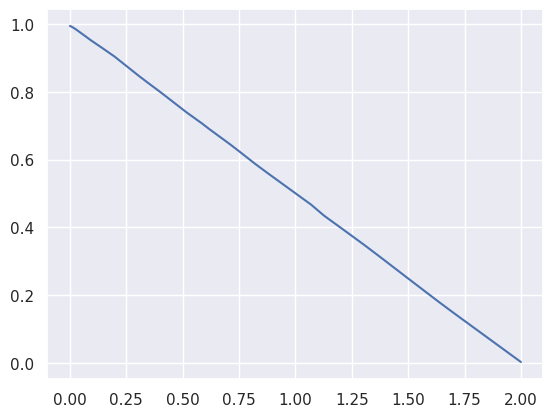

In [7]:
epochs = 1000
for t in range(epochs):
    print(f"Epoch {t+1}\n----------------------------")
    train_loop(input, model, optimizer)
output = model(input)
plt.figure()
plt.plot(input.detach().numpy(), output.detach().numpy())
plt.show()

demora pila en ajustar bien esto, holy shit

In [19]:
# compute the derivative of the model
x = input.sort().values
x.requires_grad = True
y = model(x)
Y = torch.sum(y)
Y.backward()


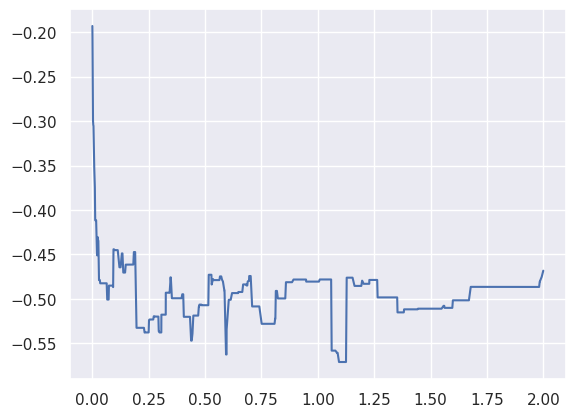

In [21]:
plt.figure()
plt.plot(x.detach().numpy(), x.grad.detach().numpy())
plt.show()